Jorge Angon, Navpreet Kloy
Kaggle Database Used: https://www.kaggle.com/datasets/surajjha101/stores-area-and-sales-data

In [ ]:
# call the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("Stores.csv")
df_original = df.copy()                   # keep a copy

df.head()


,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
0,1,1659,1961,530,66490
1,2,1461,1752,210,39820
2,3,1340,1609,720,54010
3,4,1451,1748,620,53730
4,5,1770,2111,450,46620


In [ ]:
print(df.isnull().sum()) #checking for missing values

Store ID                0
Store_Area              0
Items_Available         0
Daily_Customer_Count    0
Store_Sales             0
dtype: int64


In [ ]:
# Keep only the 2 columns we want
df_xy = df[["Daily_Customer_Count", "Store_Sales"]].copy()

# Drop rows with missing values. data has none but still running as a double check/practice
df_xy = df_xy.dropna()

# Column Names
df_xy.columns = ["Daily Customers", "Store Sales"]

df_xy.head()


,Daily Customers,Store Sales
0,530,66490
1,210,39820
2,720,54010
3,620,53730
4,450,46620


Text(0, 0.5, 'Store Sales')

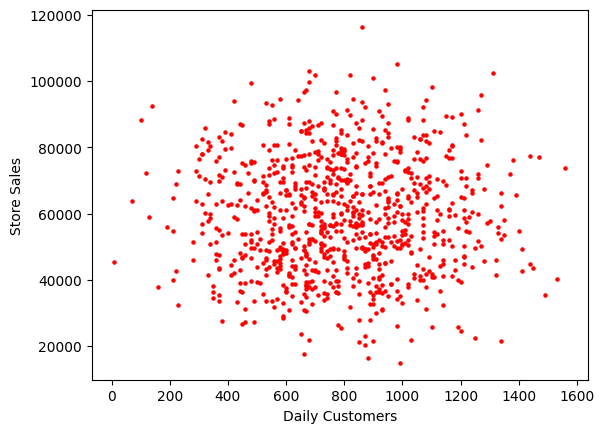

In [ ]:
#A scatter plot with the red dots size 5
plt.scatter(df_xy["Daily Customers"],df_xy["Store Sales"],c='red', s=5,
            )
plt.xlabel("Daily Customers")
plt.ylabel("Store Sales")

In [ ]:
#For now, we'll try k value 2 which splits the dots into 2 groups (k=2)
k=2
X=np.array(list(zip(df['Daily_Customer_Count'], df['Store_Sales'])))
model=KMeans(n_clusters=k)
kmeans=model.fit(X)
labels=model.predict(X)
centroids=model.cluster_centers_

print(labels)
print(centroids)


[0 1 1 1 1 1 0 1 1 1 0 1 0 1 0 0 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 1 1
 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0
 0 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1
 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1
 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0
 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 1
 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 1 0 0 0 0
 1 1 1 0 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0
 1 1 0 1 0 1 0 0 0 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1
 1 1 0 1 1 0 0 0 1 0 0 1 1 0 1 0 1 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 0 1 1 0
 0 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0
 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1
 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 0 0 0 0 0 1 0 1 1 0 1 0 1 1 1
 0 1 1 1 0 1 1 0 1 1 1 1 

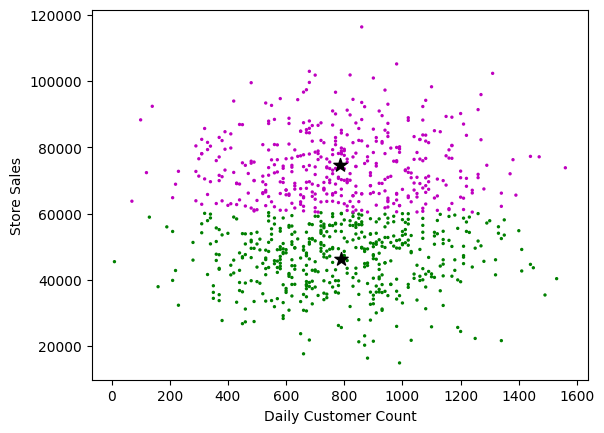

In [ ]:
#colors the dots, and adds a star in the middle of each group
c = ['m','g','b','r','y','c']
colors = [c[i % len(c)] for i in labels]

plt.scatter(df["Daily_Customer_Count"], df["Store_Sales"], c=colors, s=2)
plt.scatter(centroids[:,0], centroids[:,1], marker = "*", s=100, c="black")
plt.xlabel("Daily Customer Count")
plt.ylabel("Store Sales")
plt.show()


In [ ]:
#Used to predict what cluster for any data pt

cluster=model.predict([[35,123]])[0]
print(c[cluster])


g


In [ ]:
#To determine the silhouette coefficient/score
#Helps in choosing the best K value

from sklearn.metrics import silhouette_score

model=KMeans(n_clusters=2)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=2): {silhouette_score(X,label)}')


model=KMeans(n_clusters=3)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=3): {silhouette_score(X,label)}')


model=KMeans(n_clusters=4)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=4): {silhouette_score(X,label)}')



silhouette Score (n=2): 0.5853832546771611
silhouette Score (n=3): 0.5330042678338112
silhouette Score (n=4): 0.5271298600320583


[[  794.02298851 84296.14942529]
 [  792.14285714 51814.28571429]
 [  780.93023256 67154.18604651]
 [  777.88043478 36290.54347826]]


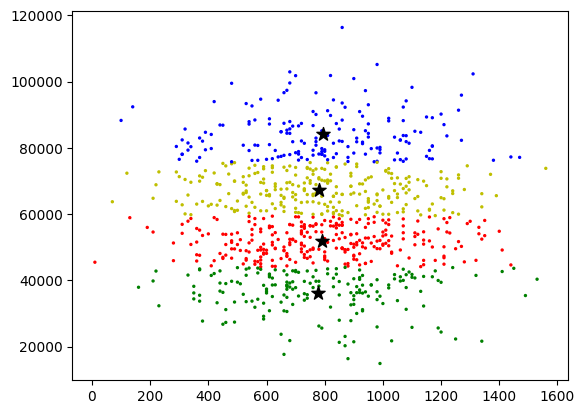

In [ ]:
#another K value run
k=4
X=np.array(list(zip(df['Daily_Customer_Count'],df['Store_Sales'])))

kmeans=KMeans(n_clusters=k)
kmeans=kmeans.fit(X)
labels=kmeans.predict(X)
centroids=kmeans.cluster_centers_

#map the labels to colors
c=['b','r','y','g','c','m']
colors=[c[i] for i in labels]

plt.scatter(df['Daily_Customer_Count'],df['Store_Sales'],c=colors,s=2)
plt.scatter(centroids[:,0],centroids[:,1],marker='*',s=100,c='black')

print(centroids)


For this dataset we chose to see the store performance using the daily customers and the store sales.
The algorithm we used was the K-means clustering algorithm so it can group similar records together and after testing K values and using the silhouette score code, the best choice was k = 2 because it had the best silhouette score (about 0.585), which means the two groups were the clearest separation in the data.
The result created two clusters which is, one with lower sales(around 46k) and another with higher sales(around 74k) which shows that there is a drastic difference in revenue even when customer traffic is similar.